# Z4 friction-early scan — analysis

Analysis of the `scan_z4_friction_early` runs: a **$\mu\times\beta_4$ grid** with constant
artificial friction $\Gamma=1$ switched **ON from $t_0$** (`frictionStartA=0`) to push the field
over the **first bump** (formation) faster, then **OFF at `frictionEndA`** (the *second* bump) so
the late evolution is the **unmodified EOM** and shows the actual scaling.

- $\mu\in\{0.1,\,0.23\}$ ($H_0=\mu$, so $H_0/\mu=1$); larger $\mu$ $\Rightarrow$ larger initial
  seed $\Rightarrow$ earlier formation, so it is released earlier:
  **`frictionEndA` $=5$ ($\mu=0.1$) / $3$ ($\mu=0.23$)**.
- $\beta_4\in\{0.1,0.3,0.5,0.7,0.9\}$.  $N=512$, $L=100$, `tMax=50` (same box as `scan_z4_prs_prod`).

**10 cards total.**  Following `Z4_prs_prod_analysis.ipynb`, every loader returns `None` for a
missing / empty / partially written run, so the notebook tries to load all 10 and silently skips /
plots-short any that are not finished — just re-run it as more complete.

**Two colour groups** (one per $\mu$), shaded by $\beta_4$ and distinguished by line style:
$\mu=0.1$ = **blue, solid**;  $\mu=0.23$ = **red, dashed** (darker shade = larger $\beta_4$).

Plot sections, each a **single panel or at most two subplots**:
1. **Wall-area parameters** $\mathcal{A}_1$ / $\mathcal{A}_2$,
2. **Scalar field** — mean $\pm\sigma$, then rms (order parameter), for **both** components,
3. **Energies** — kinetic, gradient, and the three potential terms, **per field**, plus total.

The dotted vertical line on the wall-area / total-energy panels marks the **friction release**
$\eta$ (where $a$ reaches `frictionEndA`) for each $\mu$.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import rc

# usetex matches the Z4_prs_prod_analysis.ipynb styling; flip to False if LaTeX is unavailable.
USETEX = True
rc('text', usetex=USETEX)
rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica'],
              'weight': 'bold', 'size': 16})

## Configuration

`BASE` points at the friction-early scan.  Each entry in `CONFIGS` is one card with its $\mu$,
$\beta_4$ and its friction parameters ($\Gamma=1$, on $[0,\,$`frictionEndA`$)$).  Colour = $\mu$
group (blue / red), shade = $\beta_4$ (darker = larger), line style = $\mu$ (solid / dashed).

`average_energies.txt` columns (11): `eta, Ek_1, Ek_2, Eg_1, Eg_2, Ev_1, Ev_2, Ev_3, E_tot,
Scal_type_1, Scal_type_2`.  `Ek_k`/`Eg_k` are the kinetic / gradient energies of field $k$
($\phi_0=h$, $\phi_1=a$); `Ev_1, Ev_2, Ev_3` are the three terms of the potential
$V=-\mu^2|\Phi|^2+\lambda_1|\Phi|^4-\lambda_2(\Phi^4+\Phi^{*4})$ (shared).  `Scal_type_1` =
adjacent walls ($\theta\to\theta+\pi/2$), `Scal_type_2` = diagonal walls ($\theta\to\theta+\pi$).

In [2]:
BASE = "/mt/user-batch/dpasari/scan_z4_friction_early/"

# Fixed across every card
N_LAT = 512
LSIDE = 100
DX    = LSIDE / N_LAT

MU_VALS      = [0.1, 0.23]
BETA4_VALS   = [0.1, 0.3, 0.5, 0.7, 0.9]
FRICTION_END = {0.1: 5.0, 0.23: 3.0}        # frictionEndA per mu (release at the 2nd bump)

def mu_tag(m):  # 0.1 -> 'mu0p1', 0.23 -> 'mu0p23'
    return "mu" + f"{m:g}".replace(".", "p")

def b4_tag(b):  # 0.1 -> 'b40p1', 0.3 -> 'b40p3', ...
    return "b4" + f"{b:g}".replace(".", "p")

# ── 10-card mu x beta4 matrix ──
CONFIGS = []
for m in MU_VALS:
    for b in BETA4_VALS:
        CONFIGS.append(dict(
            name=f"mu{m:g}_b{b:g}",
            dir=f"results_DWZ4_fric_{mu_tag(m)}_{b4_tag(b)}",
            mu=m, beta4=b,
            frictionGamma=1.0, frictionStartA=0.0, frictionEndA=FRICTION_END[m],
        ))

# ── Colour = mu group; shade = beta4 (darker = larger); style = mu (solid / dashed) ──
CMAPS = {0.1: plt.cm.Blues, 0.23: plt.cm.Reds}
LSS   = {0.1: "solid",      0.23: (0, (5, 2))}

def _assign_styles(configs):
    def shade(cmap, vals):
        order = sorted(set(vals))
        cols = cmap(np.linspace(0.40, 0.92, max(len(order), 1)))
        return {v: cols[i] for i, v in enumerate(order)}
    for m in MU_VALS:
        grp = [c for c in configs if c["mu"] == m]
        sh = shade(CMAPS[m], [c["beta4"] for c in grp])
        for c in grp:
            c["color"], c["ls"], c["lw"] = sh[c["beta4"]], LSS[m], 2.3

_assign_styles(CONFIGS)

GROUP_REP = {0.1: "#08519c", 0.23: "#cb181d"}

def cfg_label(c):
    return r"$\mu=%g,\ \beta_4=%g$" % (c["mu"], c["beta4"])

print(f"{len(CONFIGS)} planned cards:")
for c in CONFIGS:
    print(f"  {c['name']:12s} mu={c['mu']:.2f} beta4={c['beta4']:.1f} "
          f"frictionEndA={c['frictionEndA']:.1f}  {c['dir']}")

10 planned cards:
  mu0.1_b0.1   mu=0.10 beta4=0.1 frictionEndA=5.0  results_DWZ4_fric_mu0p1_b40p1
  mu0.1_b0.3   mu=0.10 beta4=0.3 frictionEndA=5.0  results_DWZ4_fric_mu0p1_b40p3
  mu0.1_b0.5   mu=0.10 beta4=0.5 frictionEndA=5.0  results_DWZ4_fric_mu0p1_b40p5
  mu0.1_b0.7   mu=0.10 beta4=0.7 frictionEndA=5.0  results_DWZ4_fric_mu0p1_b40p7
  mu0.1_b0.9   mu=0.10 beta4=0.9 frictionEndA=5.0  results_DWZ4_fric_mu0p1_b40p9
  mu0.23_b0.1  mu=0.23 beta4=0.1 frictionEndA=3.0  results_DWZ4_fric_mu0p23_b40p1
  mu0.23_b0.3  mu=0.23 beta4=0.3 frictionEndA=3.0  results_DWZ4_fric_mu0p23_b40p3
  mu0.23_b0.5  mu=0.23 beta4=0.5 frictionEndA=3.0  results_DWZ4_fric_mu0p23_b40p5
  mu0.23_b0.7  mu=0.23 beta4=0.7 frictionEndA=3.0  results_DWZ4_fric_mu0p23_b40p7
  mu0.23_b0.9  mu=0.23 beta4=0.9 frictionEndA=3.0  results_DWZ4_fric_mu0p23_b40p9


## Loader functions

Each loader returns `None` for a missing, empty, or partially written file — that is how the
notebook *checks whether a card has produced output before trying to plot it*.

In [3]:
def _safe_loadtxt(fpath):
    """np.loadtxt that tolerates missing / empty / mid-write (ragged) files."""
    try:
        if not os.path.exists(fpath) or os.path.getsize(fpath) == 0:
            return None
        data = np.loadtxt(fpath)
    except (FileNotFoundError, OSError, ValueError, StopIteration):
        return None
    if data.size == 0:
        return None
    if data.ndim == 1:
        data = data[np.newaxis, :]
    return data


def load_energies(path):
    """average_energies.txt -> dict, or None.  11 cols incl. the 2 Z4 wall columns."""
    data = _safe_loadtxt(os.path.join(path, "average_energies.txt"))
    if data is None or data.shape[1] < 11:
        return None
    return {
        "eta":   data[:, 0], "Ek_1": data[:, 1], "Ek_2": data[:, 2],
        "Eg_1":  data[:, 3], "Eg_2": data[:, 4], "Ev_1": data[:, 5],
        "Ev_2":  data[:, 6], "Ev_3": data[:, 7], "E_tot": data[:, 8],
        "scal1": data[:, 9],     # Scal_type_1  (adjacent,  theta -> theta+pi/2)
        "scal2": data[:, 10],    # Scal_type_2  (diagonal,  theta -> theta+pi)
    }


def load_scalar(path, idx):
    """average_scalar_{idx}.txt -> dict, or None.  idx 0 = h, 1 = a."""
    data = _safe_loadtxt(os.path.join(path, f"average_scalar_{idx}.txt"))
    if data is None or data.shape[1] < 6:
        return None
    return {
        "eta": data[:, 0], "phi": data[:, 1], "phi_prime": data[:, 2],
        "phi2": data[:, 3], "phi_prime2": data[:, 4],
        "rms_phi": data[:, 5], "rms_phi_p": data[:, 6] if data.shape[1] > 6 else data[:, 5],
    }


def load_scale_factor(path):
    """average_scale_factor.txt -> dict, or None."""
    data = _safe_loadtxt(os.path.join(path, "average_scale_factor.txt"))
    if data is None or data.shape[1] < 4:
        return None
    return {"eta": data[:, 0], "a": data[:, 1], "aprime": data[:, 2], "H": data[:, 3]}

## Load all runs — *plot only what has run*

Tries every card; `MISSING` rows are runs with no output yet and are skipped.  Runs that are still
in progress simply stop short (their last $\eta < 50$) and are plotted up to wherever they got.

In [4]:
datasets = []
for c in CONFIGS:
    path = os.path.join(BASE, c["dir"])
    en = load_energies(path)
    sf = load_scale_factor(path)
    s0 = load_scalar(path, 0)
    s1 = load_scalar(path, 1)

    ok = en is not None and sf is not None
    last_eta = f"{en['eta'][-1]:6.1f}" if ok else "  --  "
    print(f"{'OK ' if ok else 'MISSING':8s} {c['name']:12s}  last_eta={last_eta}  {c['dir']}")

    d = dict(c)
    d.update(label=cfg_label(c), energies=en, scale_factor=sf, scalar_0=s0, scalar_1=s1)
    datasets.append(d)

ready = [d for d in datasets if d["energies"] is not None and d["scale_factor"] is not None]
print(f"\nReady: {len(ready)} / {len(datasets)}")

OK       mu0.1_b0.1    last_eta=  49.9  results_DWZ4_fric_mu0p1_b40p1
OK       mu0.1_b0.3    last_eta=  49.9  results_DWZ4_fric_mu0p1_b40p3
OK       mu0.1_b0.5    last_eta=  49.9  results_DWZ4_fric_mu0p1_b40p5
OK       mu0.1_b0.7    last_eta=  49.9  results_DWZ4_fric_mu0p1_b40p7
OK       mu0.1_b0.9    last_eta=  49.9  results_DWZ4_fric_mu0p1_b40p9
OK       mu0.23_b0.1   last_eta=  49.9  results_DWZ4_fric_mu0p23_b40p1
OK       mu0.23_b0.3   last_eta=  49.9  results_DWZ4_fric_mu0p23_b40p3
OK       mu0.23_b0.5   last_eta=  49.9  results_DWZ4_fric_mu0p23_b40p5
OK       mu0.23_b0.7   last_eta=  44.7  results_DWZ4_fric_mu0p23_b40p7
OK       mu0.23_b0.9   last_eta=  43.6  results_DWZ4_fric_mu0p23_b40p9

Ready: 10 / 10


## Plot helpers

In [5]:
def paper_ax(ax, xlabel=r"$\eta$", ylabel="", title=""):
    ax.set_xlabel(xlabel, fontsize=24)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=24)
    if title:
        ax.set_title(title, fontsize=20)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.tick_params(axis='both', which='both', direction='in', labelsize=18, pad=6)
    ax.tick_params(which='major', length=9)
    ax.tick_params(which='minor', length=4)
    ax.minorticks_on()
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)


def area_param(en_key, d):
    """Wall-area parameter A_k = scal_k / (2 a H), eta-aligned."""
    en, sf = d["energies"], d["scale_factor"]
    n = min(len(en["eta"]), len(sf["a"]))
    scal, a, H = en[en_key][:n], sf["a"][:n], sf["H"][:n]
    with np.errstate(divide='ignore', invalid='ignore'):
        A = scal / (2.0 * a * H)
    return en["eta"][:n], A


def breaking_onset(d):
    """eta at which Ev_1 first goes negative (symmetry breaking), or None."""
    en = d["energies"]
    neg = np.where(en["Ev_1"] < 0)[0]
    return en["eta"][neg[0]] if neg.size else None


def friction_release_eta(d):
    """eta at which a first reaches frictionEndA (friction turns OFF), or None."""
    sf = d["scale_factor"]
    if sf is None:
        return None
    idx = np.where(sf["a"] >= d["frictionEndA"])[0]
    return sf["eta"][idx[0]] if idx.size else None


def mark_friction_release(ax):
    """Faint dotted vertical line at the friction-release eta for each mu group."""
    for m in MU_VALS:
        reps = [d for d in ready if d["mu"] == m]
        if not reps:
            continue
        eta_r = friction_release_eta(reps[0])
        if eta_r is not None:
            ax.axvline(eta_r, color=GROUP_REP[m], ls=':', lw=1.4, alpha=0.8, zorder=1)


def config_handles(items):
    return [Line2D([0], [0], color=d["color"], lw=max(d["lw"], 2.4), linestyle=d["ls"],
                   label=d["label"]) for d in items]

# V_0 = |Ev_1| at phi=0 (value of the mass term at the symmetric maximum)
V0 = float(ready[0]["energies"]["Ev_1"][0]) if ready else 0.0
print(f"Ready runs: {len(ready)};  V0 (Ev_1 at phi=0) = {V0:.3e}")
for m in MU_VALS:
    reps = [d for d in ready if d["mu"] == m]
    if reps:
        print(f"  mu={m}: friction released at eta ~ {friction_release_eta(reps[0]):.2f} "
              f"(a reaches frictionEndA={FRICTION_END[m]})")

Ready runs: 10;  V0 (Ev_1 at phi=0) = 2.489e-03
  mu=0.1: friction released at eta ~ 4.00 (a reaches frictionEndA=5.0)
  mu=0.23: friction released at eta ~ 2.00 (a reaches frictionEndA=3.0)


## 1. Wall-area parameters $\mathcal{A}_1$ and $\mathcal{A}_2$

$\mathcal{A}_k = \mathrm{Scal\_type\_}k / (2aH)$.  **Left** = type-1 (adjacent), **right** = type-2
(diagonal).  Markers ($\bullet$) flag each run's symmetry-breaking onset (first $E_{v,1}<0$):
$\mathcal{A}$ is only physical wall area to the **right** of the marker.  The dotted vertical lines
mark the friction release $\eta$ for each $\mu$ — to their left the network is being driven by
$\Gamma=1$; to their right it is the unmodified EOM.

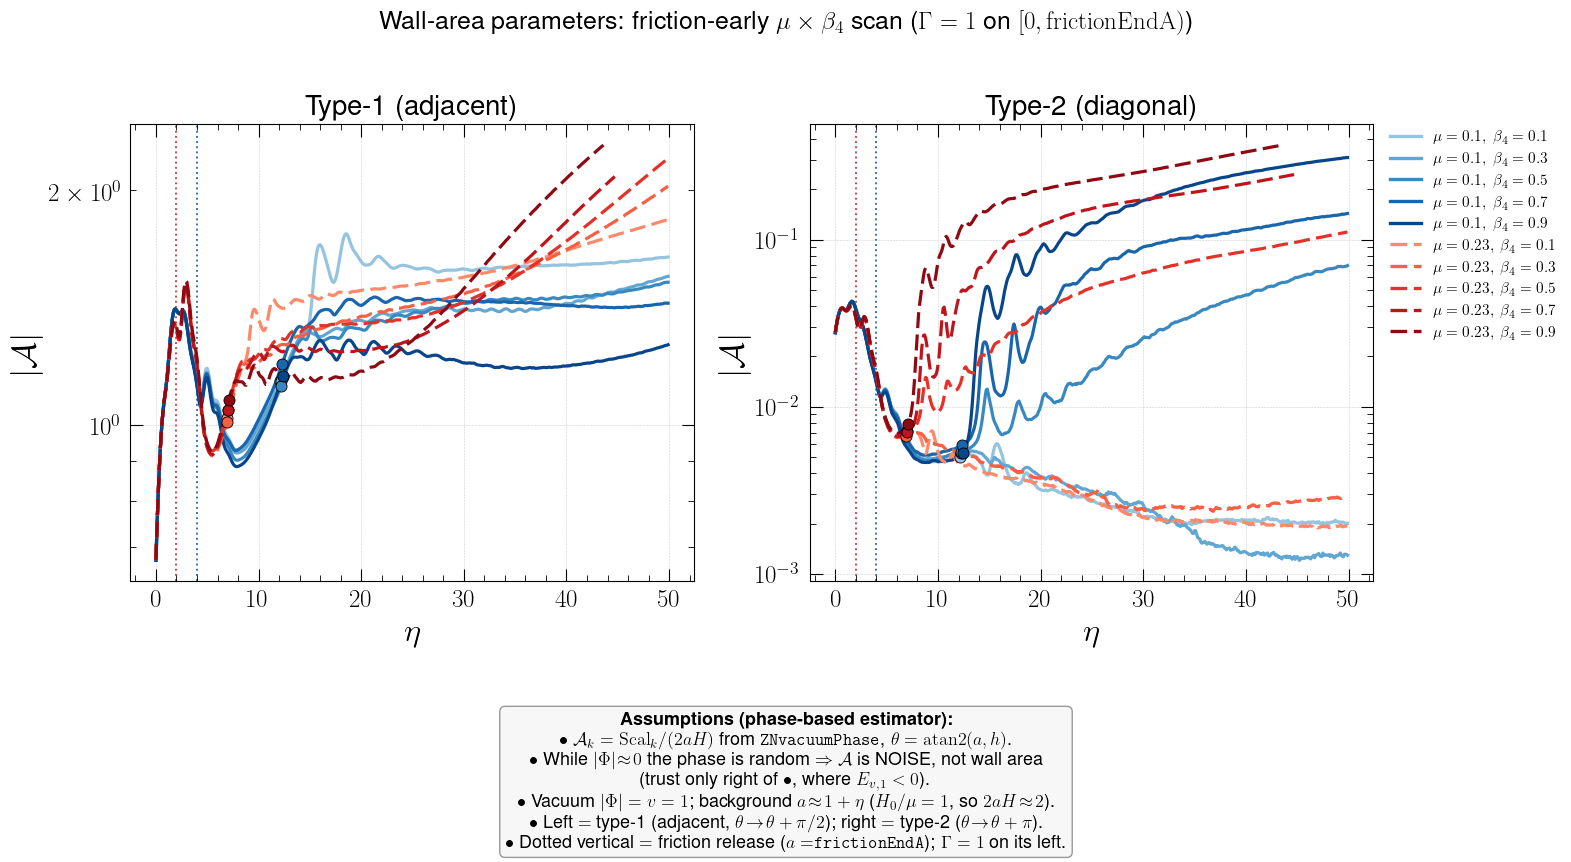

In [6]:
ASSUMPTIONS = "\n".join([
    r"\textbf{Assumptions (phase-based estimator):}",
    r"$\bullet$ $\mathcal{A}_k=\mathrm{Scal}_k/(2aH)$ from \texttt{ZNvacuumPhase}, $\theta=\mathrm{atan2}(a,h)$.",
    r"$\bullet$ While $|\Phi|\!\approx\!0$ the phase is random $\Rightarrow$ $\mathcal{A}$ is NOISE, not wall area",
    r"\;\;(trust only right of $\bullet$, where $E_{v,1}<0$).",
    r"$\bullet$ Vacuum $|\Phi|=v=1$; background $a\!\approx\!1+\eta$ ($H_0/\mu=1$, so $2aH\!\approx\!2$).",
    r"$\bullet$ Left $=$ type-1 (adjacent, $\theta\!\to\!\theta+\pi/2$); right $=$ type-2 ($\theta\!\to\!\theta+\pi$).",
    r"$\bullet$ Dotted vertical $=$ friction release ($a=$\texttt{frictionEndA}); $\Gamma=1$ on its left.",
])

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharex=True)
for d in ready:
    eta1, A1 = area_param("scal1", d)
    eta2, A2 = area_param("scal2", d)
    axes[0].plot(eta1, np.abs(A1), color=d["color"], ls=d["ls"], lw=d["lw"])
    axes[1].plot(eta2, np.abs(A2), color=d["color"], ls=d["ls"], lw=d["lw"])
    eta_b = breaking_onset(d)
    if eta_b is not None:
        for ax, (eta, A) in zip(axes, [(eta1, A1), (eta2, A2)]):
            k = int(np.argmin(np.abs(eta - eta_b)))
            ax.plot(eta[k], abs(A[k]), 'o', color=d["color"], ms=8,
                    mec='k', mew=0.6, zorder=5)

for ax, ttl in zip(axes, [r"Type-1 (adjacent)", r"Type-2 (diagonal)"]):
    paper_ax(ax, ylabel=r"$|\mathcal{A}|$", title=ttl)
    ax.set_yscale('log')
    mark_friction_release(ax)

axes[1].legend(handles=config_handles(ready), fontsize=11, frameon=False,
               loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
fig.text(0.5, -0.06, ASSUMPTIONS, ha='center', va='top', fontsize=13,
         bbox=dict(boxstyle='round', fc='#f7f7f7', ec='0.6'))
fig.suptitle(r"Wall-area parameters: friction-early $\mu\times\beta_4$ scan "
             r"($\Gamma=1$ on $[0,\mathrm{frictionEndA})$)", fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig("Z4fric_early_area.pdf", bbox_inches="tight")
plt.show()

## 2. Scalar field — mean and rms

Components: $\phi_0=h$, $\phi_1=a$ (the two real parts of $\Phi$).  At a Z4 vacuum $|\Phi|=v=1$
each component sits near $\pm v/\sqrt2\approx0.707$.  First the **mean** $\pm\sigma$, then the
**rms** $\sqrt{\langle\phi^2\rangle}$ (the symmetry-breaking order parameter) — for **both**
fields.

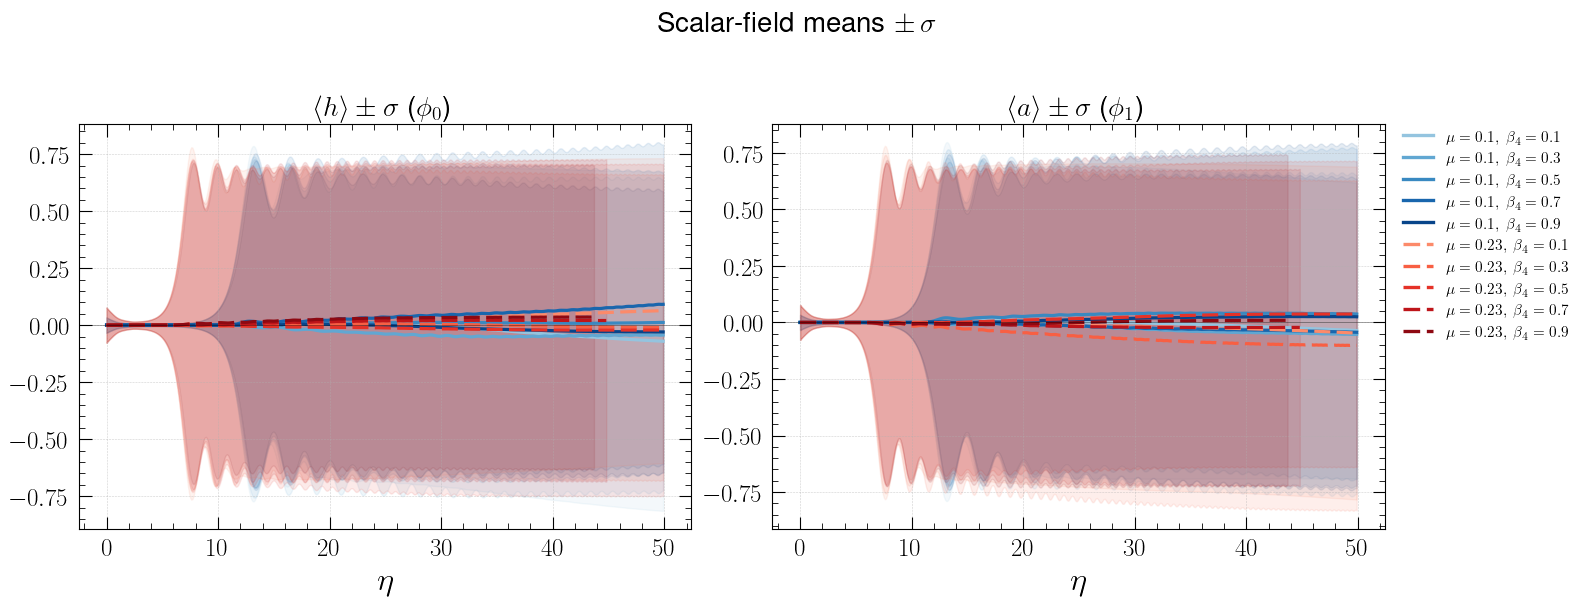

In [7]:
# --- 2a. mean +/- sigma ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
for d in ready:
    for ax, fkey in zip(axes, ("scalar_0", "scalar_1")):
        sc = d.get(fkey)
        if sc is None:
            continue
        sigma = np.sqrt(np.maximum(sc["phi2"] - sc["phi"]**2, 0.0))
        ax.fill_between(sc["eta"], sc["phi"] - sigma, sc["phi"] + sigma,
                        alpha=0.10, color=d["color"])
        ax.plot(sc["eta"], sc["phi"], color=d["color"], ls=d["ls"], lw=d["lw"])

for ax, ttl in zip(axes, [r"$\langle h\rangle\pm\sigma$  ($\phi_0$)",
                          r"$\langle a\rangle\pm\sigma$  ($\phi_1$)"]):
    paper_ax(ax, ylabel="", title=ttl)
    ax.axhline(0, color='k', lw=0.6, alpha=0.4)
axes[1].legend(handles=config_handles(ready), fontsize=11, frameon=False,
               loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
fig.suptitle(r"Scalar-field means  $\pm\,\sigma$", fontsize=20, y=1.02)
plt.tight_layout()
plt.savefig("Z4fric_early_field_mean.pdf", bbox_inches="tight")
plt.show()

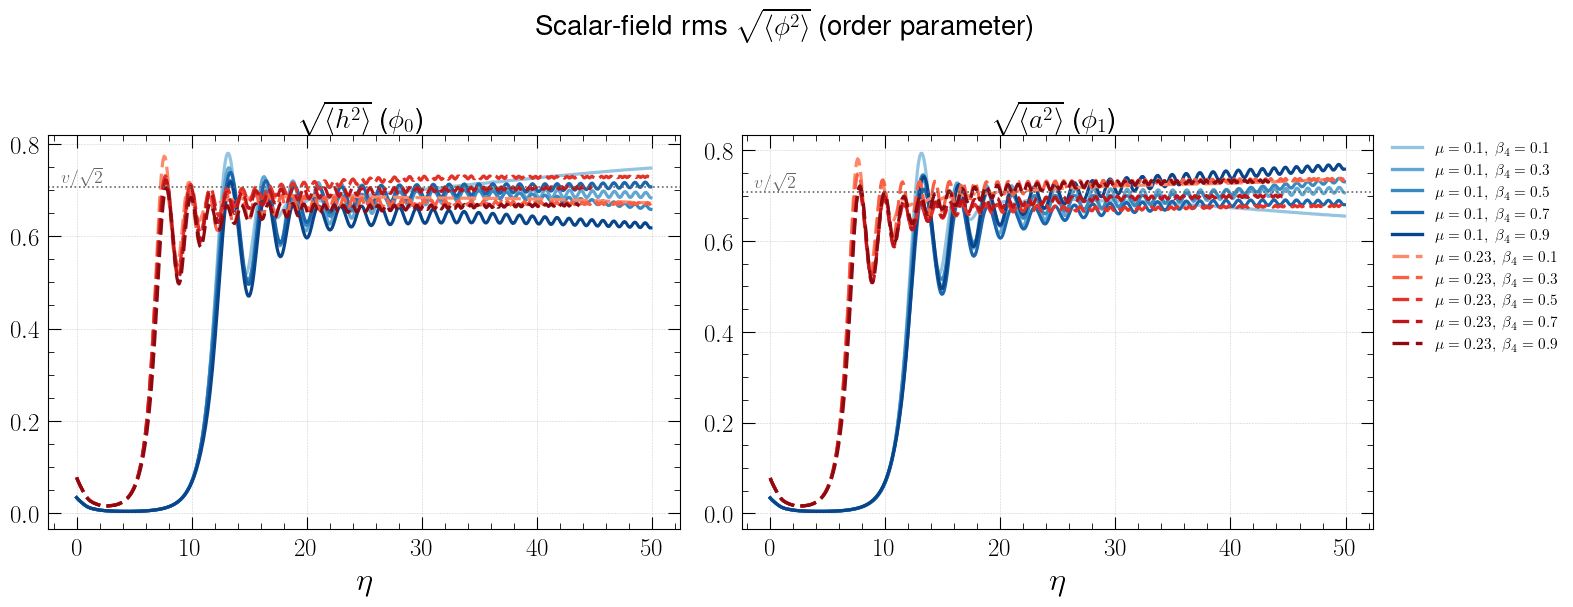

In [8]:
# --- 2b. rms (order parameter) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
for d in ready:
    for ax, fkey in zip(axes, ("scalar_0", "scalar_1")):
        sc = d.get(fkey)
        if sc is None:
            continue
        ax.plot(sc["eta"], np.sqrt(np.maximum(sc["phi2"], 0.0)),
                color=d["color"], ls=d["ls"], lw=d["lw"])

for ax, ttl in zip(axes, [r"$\sqrt{\langle h^2\rangle}$  ($\phi_0$)",
                          r"$\sqrt{\langle a^2\rangle}$  ($\phi_1$)"]):
    paper_ax(ax, ylabel="", title=ttl)
    ax.axhline(1/np.sqrt(2), color='0.4', ls=':', lw=1.2)
    ax.text(0.02, 1/np.sqrt(2), r"$v/\sqrt2$", color='0.4', fontsize=13,
            va='bottom', ha='left', transform=ax.get_yaxis_transform())
axes[1].legend(handles=config_handles(ready), fontsize=11, frameon=False,
               loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
fig.suptitle(r"Scalar-field rms  $\sqrt{\langle\phi^2\rangle}$  (order parameter)",
             fontsize=20, y=1.02)
plt.tight_layout()
plt.savefig("Z4fric_early_field_rms.pdf", bbox_inches="tight")
plt.show()

## 3. Energies — per field, every component

For each field $\phi_0=h$, $\phi_1=a$ we plot its **kinetic** $E_{k}$ and **gradient** $E_{g}$;
then the **three potential terms** $E_{v,1}$ (mass $-\mu^2|\Phi|^2$, the breaking term),
$E_{v,2}$ (quartic $\lambda_1|\Phi|^4$), $E_{v,3}$ (Z4 $-\lambda_2(\Phi^4+\Phi^{*4})$), and the
**total** $E_{\rm tot}$.  Every figure is two panels.

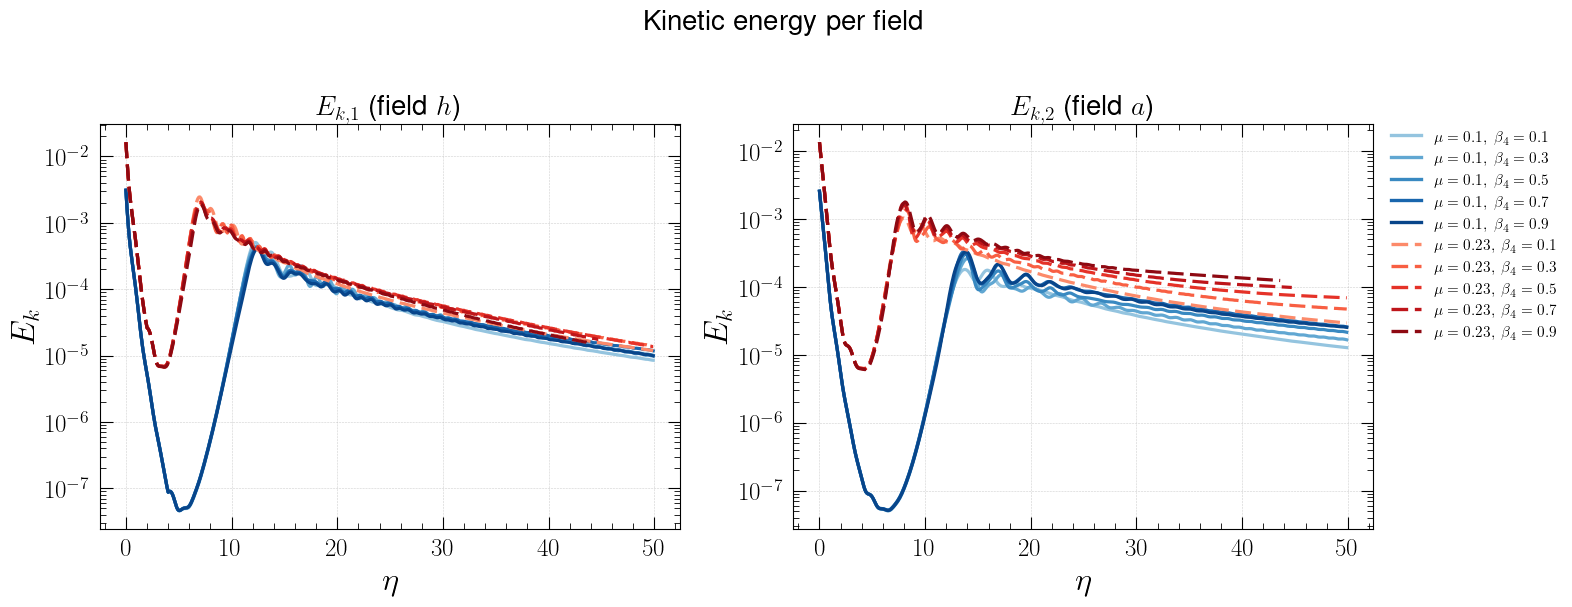

In [9]:
# --- 3a. kinetic energy, per field ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
for d in ready:
    en = d["energies"]
    axes[0].plot(en["eta"], en["Ek_1"], color=d["color"], ls=d["ls"], lw=d["lw"])
    axes[1].plot(en["eta"], en["Ek_2"], color=d["color"], ls=d["ls"], lw=d["lw"])
for ax, ttl in zip(axes, [r"$E_{k,1}$  (field $h$)", r"$E_{k,2}$  (field $a$)"]):
    paper_ax(ax, ylabel=r"$E_k$", title=ttl)
    ax.set_yscale('log')
axes[1].legend(handles=config_handles(ready), fontsize=11, frameon=False,
               loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
fig.suptitle(r"Kinetic energy per field", fontsize=20, y=1.02)
plt.tight_layout()
plt.savefig("Z4fric_early_energy_kinetic.pdf", bbox_inches="tight")
plt.show()

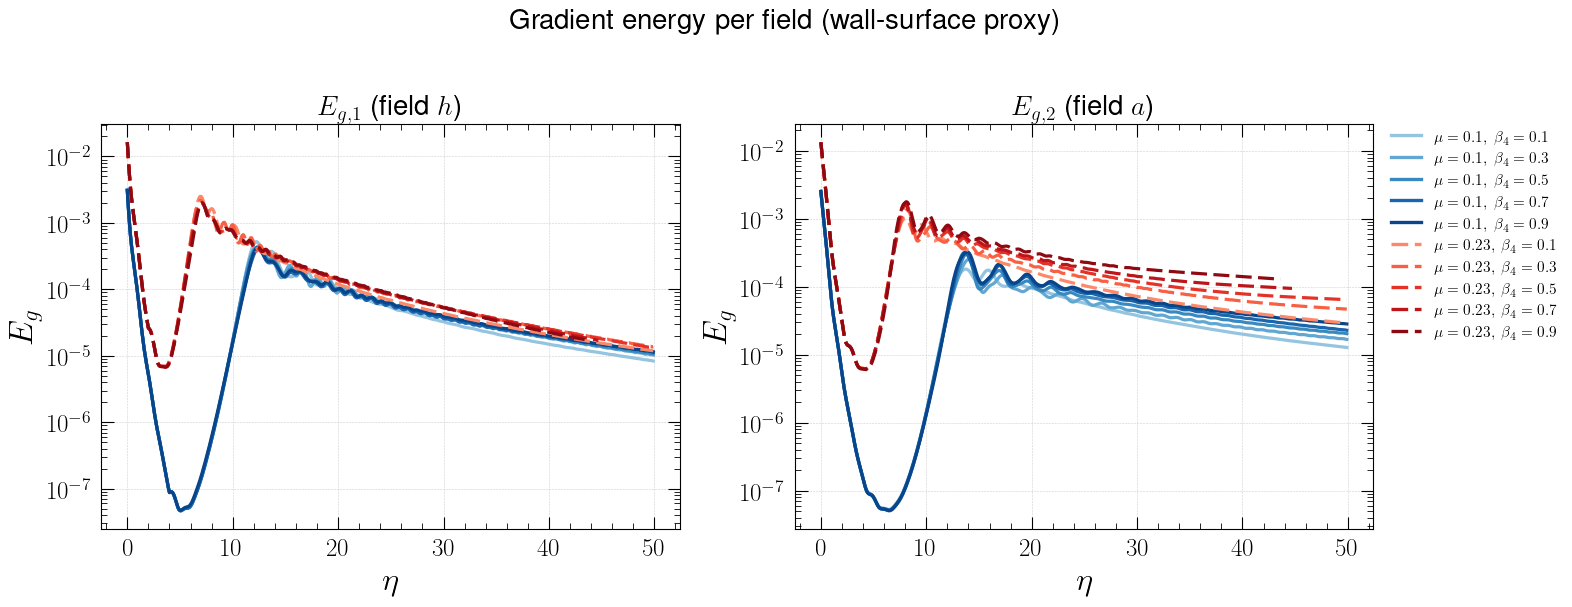

In [10]:
# --- 3b. gradient energy, per field (proxy for wall surface) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
for d in ready:
    en = d["energies"]
    axes[0].plot(en["eta"], en["Eg_1"], color=d["color"], ls=d["ls"], lw=d["lw"])
    axes[1].plot(en["eta"], en["Eg_2"], color=d["color"], ls=d["ls"], lw=d["lw"])
for ax, ttl in zip(axes, [r"$E_{g,1}$  (field $h$)", r"$E_{g,2}$  (field $a$)"]):
    paper_ax(ax, ylabel=r"$E_g$", title=ttl)
    ax.set_yscale('log')
axes[1].legend(handles=config_handles(ready), fontsize=11, frameon=False,
               loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
fig.suptitle(r"Gradient energy per field (wall-surface proxy)", fontsize=20, y=1.02)
plt.tight_layout()
plt.savefig("Z4fric_early_energy_gradient.pdf", bbox_inches="tight")
plt.show()

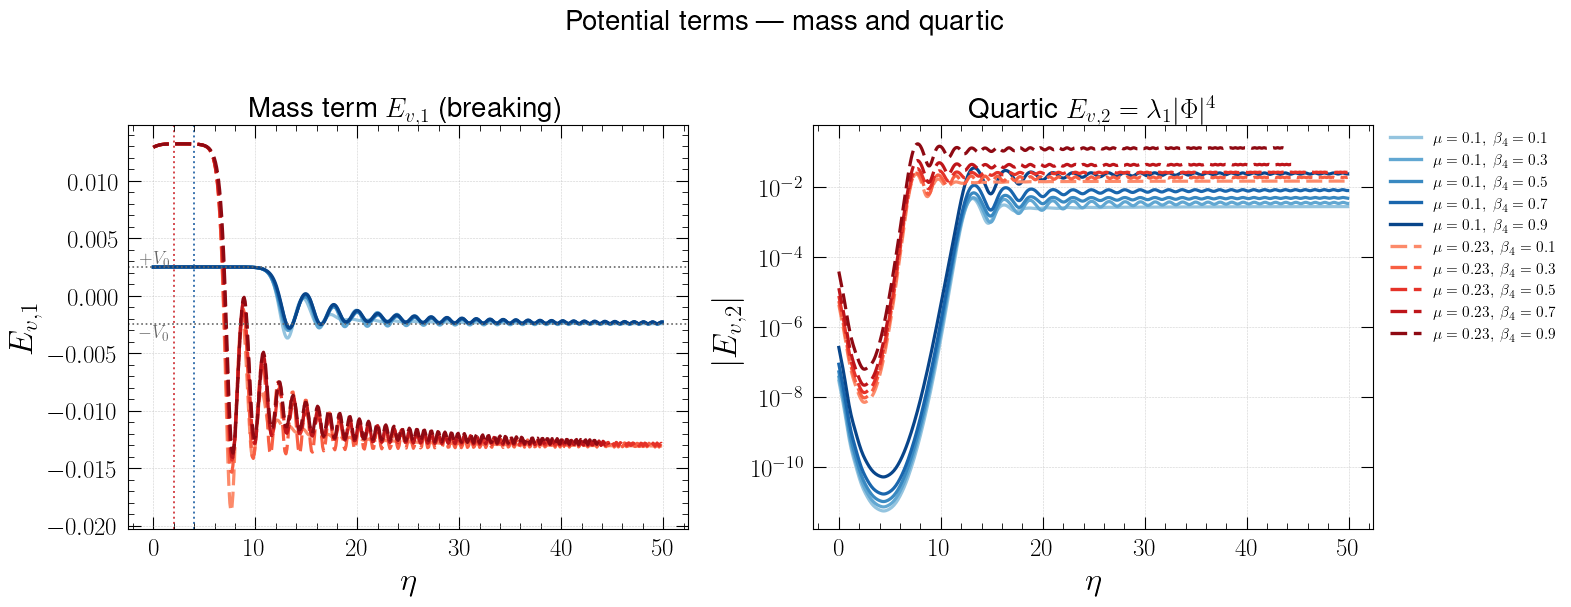

In [11]:
# --- 3c. potential terms 1 & 2 ---
# Ev_1 = mass term (-mu^2|Phi|^2): starts at +V0 (symmetric max), crosses to -V0 on breaking.
# Ev_2 = quartic (lambda_1 |Phi|^4): positive, grows as |Phi| -> v.
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
for d in ready:
    en = d["energies"]
    axes[0].plot(en["eta"], en["Ev_1"], color=d["color"], ls=d["ls"], lw=d["lw"])
    axes[1].plot(en["eta"], np.abs(en["Ev_2"]), color=d["color"], ls=d["ls"], lw=d["lw"])

paper_ax(axes[0], ylabel=r"$E_{v,1}$", title=r"Mass term $E_{v,1}$ (breaking)")
for s in (+1, -1):
    axes[0].axhline(s * V0, color='0.4', ls=':', lw=1.2)
axes[0].text(0.02, +V0, r"$+V_0$", color='0.4', fontsize=13, va='bottom',
             transform=axes[0].get_yaxis_transform())
axes[0].text(0.02, -V0, r"$-V_0$", color='0.4', fontsize=13, va='top',
             transform=axes[0].get_yaxis_transform())
mark_friction_release(axes[0])
paper_ax(axes[1], ylabel=r"$|E_{v,2}|$", title=r"Quartic $E_{v,2}=\lambda_1|\Phi|^4$")
axes[1].set_yscale('log')
axes[1].legend(handles=config_handles(ready), fontsize=11, frameon=False,
               loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
fig.suptitle(r"Potential terms — mass and quartic", fontsize=20, y=1.02)
plt.tight_layout()
plt.savefig("Z4fric_early_energy_pot12.pdf", bbox_inches="tight")
plt.show()

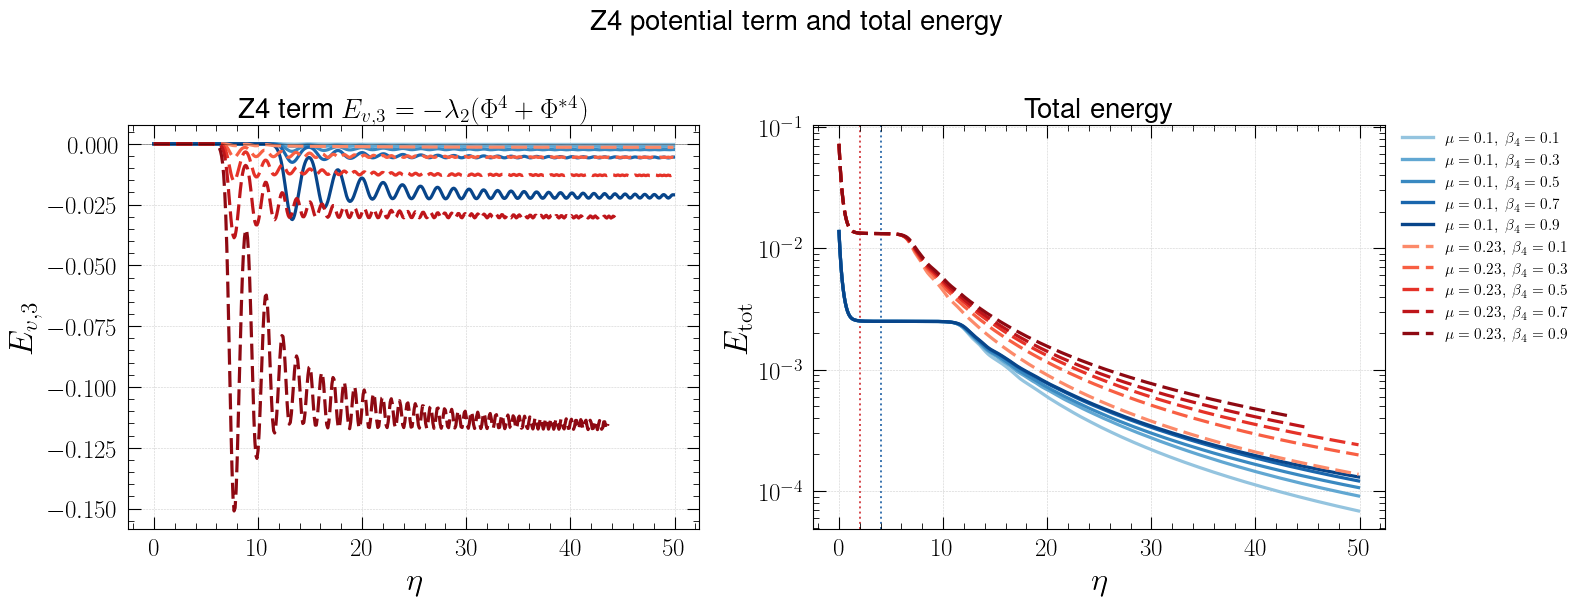

In [12]:
# --- 3d. potential term 3 (Z4) & total energy ---
# Ev_3 = Z4 term -lambda_2(Phi^4 + Phi*^4): can change sign -> linear scale.
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
for d in ready:
    en = d["energies"]
    axes[0].plot(en["eta"], en["Ev_3"], color=d["color"], ls=d["ls"], lw=d["lw"])
    axes[1].plot(en["eta"], en["E_tot"], color=d["color"], ls=d["ls"], lw=d["lw"])

paper_ax(axes[0], ylabel=r"$E_{v,3}$", title=r"Z4 term $E_{v,3}=-\lambda_2(\Phi^4+\Phi^{*4})$")
axes[0].axhline(0, color='k', lw=0.6, alpha=0.4)
paper_ax(axes[1], ylabel=r"$E_{\rm tot}$", title=r"Total energy")
axes[1].set_yscale('log')
mark_friction_release(axes[1])
axes[1].legend(handles=config_handles(ready), fontsize=11, frameon=False,
               loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
fig.suptitle(r"Z4 potential term and total energy", fontsize=20, y=1.02)
plt.tight_layout()
plt.savefig("Z4fric_early_energy_pot3_tot.pdf", bbox_inches="tight")
plt.show()

## Summary — breaking onset and friction release

Per ready run: symmetry-breaking onset ($E_{v,1}<0$), friction-release $\eta$ (where $a$ reaches
`frictionEndA`), peak $\sqrt{\langle h^2\rangle}$, and the final $\eta$ reached (runs still in
progress stop short).

In [13]:
print(f"{'card':14s} {'mu':>5s} {'beta4':>6s} {'fricEndA':>8s} "
      f"{'release@eta':>12s} {'break@eta':>10s} {'peak rms h':>11s} {'final eta':>10s}")
print("-" * 82)
for d in ready:
    eta_b = breaking_onset(d)
    eta_r = friction_release_eta(d)
    s0 = d.get("scalar_0")
    peak = np.sqrt(np.maximum(s0["phi2"], 0.0)).max() if s0 is not None else float('nan')
    print(f"{d['name']:14s} {d['mu']:>5.2f} {d['beta4']:>6.1f} {d['frictionEndA']:>8.1f} "
          f"{(f'{eta_r:.2f}' if eta_r is not None else 'none'):>12s} "
          f"{(f'{eta_b:.1f}' if eta_b is not None else 'none'):>10s} "
          f"{peak:>11.3f} {d['energies']['eta'][-1]:>10.1f}")

card              mu  beta4 fricEndA  release@eta  break@eta  peak rms h  final eta
----------------------------------------------------------------------------------
mu0.1_b0.1      0.10    0.1      5.0         4.00       12.1       0.779       49.9
mu0.1_b0.3      0.10    0.3      5.0         4.00       12.2       0.748       49.9
mu0.1_b0.5      0.10    0.5      5.0         4.00       12.2       0.721       49.9
mu0.1_b0.7      0.10    0.7      5.0         4.00       12.3       0.738       49.9
mu0.1_b0.9      0.10    0.9      5.0         4.00       12.4       0.718       49.9
mu0.23_b0.1     0.23    0.1      3.0         2.00        6.9       0.773       49.9
mu0.23_b0.3     0.23    0.3      3.0         2.00        6.9       0.722       49.9
mu0.23_b0.5     0.23    0.5      3.0         2.00        7.0       0.731       49.9
mu0.23_b0.7     0.23    0.7      3.0         2.00        7.0       0.722       44.7
mu0.23_b0.9     0.23    0.9      3.0         2.00        7.1       0.705     